In [70]:
#using PlotlyJS
using UMAP: umap
using Plots

include("/home/harut/LWD/fx/foldexity/src/fxio.jl")
include("/home/harut/LWD/fx/foldexity/src/kabsch_umeyama.jl")

dihedral (generic function with 1 method)

In [ ]:
function virtors(xyzmatrix::Matrix{T}) where {T}

    if size(xyzmatrix) != (4, 3)

        error("Input matrix must be of size (4, 3)!")

    end

    p1 = xyzmatrix[1,1:3]
    p2 = xyzmatrix[2,1:3]
    p3 = xyzmatrix[3,1:3]
    p4 = xyzmatrix[4,1:3]

    b1 = p2 .- p1
    b2 = p3 .- p2
    b3 = p4 .- p3

    # Normalize the vectors
    norm_b1 = norm(b1)
    norm_b2 = norm(b2)
    norm_b3 = norm(b3)

    norm_vec1 = b1 ./ norm_b1
    norm_vec2 = b2 ./ norm_b2
    norm_vec3 = b3 ./ norm_b3

    # Compute normals
    n1 = cross(norm_vec1, norm_vec2)
    n2 = cross(norm_vec2, norm_vec3)

    # Compute the dihidral
    x = dot(n1, n2)
    y = dot(cross(n1, n2), norm_vec2)

    dihidral = atan(y, x) * (180 / π)  # Converted to degrees * (180 / π)

    # Compute angles
    angle1 = acos(dot(b1, b2) / (norm_b1 * norm_b2)) * (180 / π)
    angle2 = acos(dot(b2, b3) / (norm_b2 * norm_b3)) * (180 / π)



    return [dihidral, angle1, angle2]

end

virtors(xyz)

In [ ]:
function pdb2kmers(pdbpath)
    virtorses = Vector{Vector{Float64}}()  
    seqxyz = pdb2seqxyz(pdbpath)
    for fourmer in coords2kmers(seqxyz, 4, "ca")
        push!(virtorses, virtors(fourmer[1:4,2:4]))
    end
    return virtorses
end

pdb2kmers (generic function with 1 method)

In [ ]:
virtorses = pdb2kmers("../testpdb/3EFM.pdb")

In [102]:
hcat(virtorses...)

3×190 Matrix{Float64}:
 91.4734  168.461   97.6207  -151.08    …  -165.454   -176.144   179.753
 53.2881   68.6452  83.129     44.4712       61.7402    59.5713   58.9319
 59.959    78.6724  85.3073    89.5514       50.5616    44.7704   53.5014

In [115]:
umap_model = umap(hcat(virtorses...); n_neighbors=10, min_dist=0.001, n_epochs=200)


2×190 Matrix{Float64}:
  5.00096  8.95302   5.01732  -6.56064  …  -8.37714  -9.30649  8.71268
 -4.54414  3.26718  -4.1847    0.74418      3.05929   3.4962   3.43461

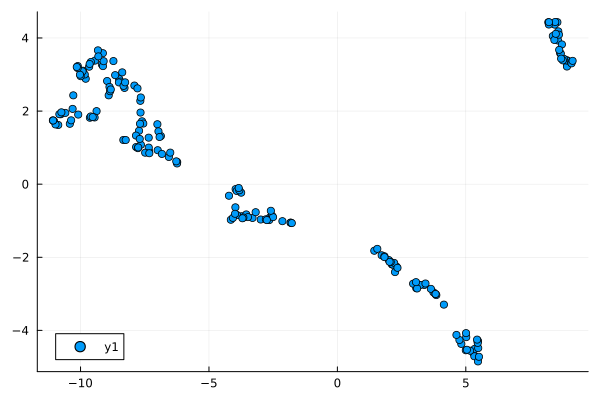

In [118]:
scatter(umap_model[1,:], umap_model[2,:])

In [ ]:
function catrace(seqxyz)

    trace_points = scatter3d(
            x=seqxyz[:,2], y=seqxyz[:,3], z=seqxyz[:,4],
            mode="markers+text",
            marker=attr(size=2, color="red"),
            text=seqxyz[:,1],
            textposition="top center"
        )

    trace_lines = scatter3d(
            x=seqxyz[:,2], y=seqxyz[:,3], z=seqxyz[:,4],
            mode="lines",
            line=attr(width=4, color="blue")
        )
        
    layout = Layout(
            title="Dihedral Angle Visualization",
            width=800,    # Set plot width
            height=600,   # Set plot height
            scene=attr(
                xaxis=attr(visible=false),
                yaxis=attr(visible=false),
                zaxis=attr(visible=false),
                camera=attr(
                    projection=attr(type="orthographic")  # Set perspective view
                )
            )
        )

    return plot([trace_lines, trace_points], layout)
end

catrace(seqxyz)